In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from pathlib import Path
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)
import torch_pruning as tp


from src.dataset import *
from src.lightning import *
from src.models import *
from src.params import *
from src.utils import *
from src.deployment import *



In [ ]:

files_dir = PROCESSED_DIR / "cropped" / "files"
metadata = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 32, num_workers= 8, verbose= False)

In [ ]:
#instantiate val_dataloader
dm.setup()

#dict to store results
results_pruning = {
    "sizes": [], "latency": [], "score": [],
    "pruning_ratio": [], "sizes_tuned": [], 
    "latency_tuned": [], "score_tuned": []
}

[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273_min_vote_1.json
[setup] Cache loaded — 5 folds found


# TEST BEST PRUNING RATIO

In [ ]:

imp = tp.importance.MagnitudeImportance(p= 2)
dummy_input = torch.randn(1,4,100,25)

for pruning_ratio in [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.25, 0.3, 0.4]:
    print(f"testing ratio {pruning_ratio}")
    
    # PRUNING
    model = instantiate_model(BEST_WEIGHTS_PATH) # return a lit_model.model object
    ignored_layers = get_ignored_layers(model)
    pruner = tp.pruner.MagnitudePruner(model= model,
                                    example_inputs= dummy_input,
                                    importance= imp,
                                    pruning_ratio= pruning_ratio,
                                    ignored_layers= ignored_layers)

    pruner.step() #pruning occuring "in place"

    
    size_pruned, latency_pruned, score_pruned = model_efficience_report(model= model, datamodule= dm)
    results_pruning["sizes"].append(size_pruned)
    results_pruning["latency"].append(latency_pruned)
    results_pruning["score"].append(score_pruned)
    results_pruning["pruning_ratio"].append(pruning_ratio)
    
    # PRUNED MODEL FINE-TUNING
    #create a lightning module for prune model
    model.train() #go back into train model for the model (set to eval in model_efficience_report)
    lit_model = BrainLightning(model = model, 
                          n_classes= 6,
                          lr = BEST_TRAINING_PARAMS["lr"] /10,
                          mixup = True,
                          mixup_alpha= BEST_TRAINING_PARAMS["mixup_alpha"],
                          weight_decay= BEST_TRAINING_PARAMS["weight_decay"],
                          t_max= 15,
                          scheduler= True)
    
    callbacks = [
    ModelCheckpoint(
        dirpath= CHECKPOINTS_DIR / f"pruning_{pruning_ratio}",
        monitor= "val_loss",
        mode= "min",
        save_top_k= 1,
        save_last= False,
        filename= "{epoch:02d}-{val_loss:.3f}",
    ),
    EarlyStopping(
        monitor= "val_loss",
        patience = 5,
        mode= "min",
        min_delta= 1e-3
        )
    ]
    
    trainer = pl.Trainer(
        accelerator= "auto",
        devices= "auto",
        precision = "bf16-mixed",
        callbacks = callbacks,
        logger = False,
        max_epochs= 15,
        enable_progress_bar= True,
        log_every_n_steps= 10
    )
    
    #fine tune pruned model
    trainer.fit(lit_model, dm)
    #tmodel in memory is last epoch. what we want is best epoch.
    best_checkpoint = callbacks[0].best_model_path #get best model
    #load weights corresponding to best epoch
    lit_best = BrainLightning.load_from_checkpoint(best_checkpoint, model= model )
    size_tuned, latency_tuned, score_tuned = model_efficience_report(model= lit_best.model, datamodule= dm)
    results_pruning["sizes_tuned"].append(size_tuned)
    results_pruning["latency_tuned"].append(latency_tuned)
    results_pruning["score_tuned"].append(score_tuned)
    
    
    

testing ratio 0
load model
calculate size and latency
calculate model inference score


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



-----------------------------------
  Model Efficiency Report
-----------------------------------
  Total params:        1,100,712
  Trainable params:    1,100,712
  Model size (MB):     4.204
-----------------------------------
  Median latency (ms): 3.99
  Max latency (ms):    7.72
-----------------------------------
  KL score: 0.6762
-----------------------------------

[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273_min_vote_1.json
[setup] Cache loaded — 5 folds found


/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptunaModel │  1.1 M │ train │     0 │
│ 1 │ criterion │ KLDivLoss   │      0 │ train │     0 │
└───┴───────────┴─────────────┴────────┴───────┴───────┘

...

Epoch 010 | val_loss:   0.6867

Epoch 010 - train_loss: 0.4793 - lr: 4.76e-05

Epoch 011 | val_loss:   0.6892

Epoch 011 - train_loss: 0.4825 - lr: 2.79e-05

load model
calculate size and latency
calculate model inference score

-----------------------------------
  Model Efficiency Report
-----------------------------------
  Total params:        438,230
  Trainable params:    438,230
  Model size (MB):     1.675
-----------------------------------
  Median latency (ms): 2.79
  Max latency (ms):    8.71
-----------------------------------
  KL score: 0.6852
-----------------------------------



In [6]:



result_df =  pd.DataFrame(results_pruning)



In [7]:
result_df

,sizes,latency,score,pruning_ratio,sizes_tuned,latency_tuned,score_tuned
0,4.203674,3.990563,0.676170,0.000,4.203674,4.034625,0.675397
1,4.122768,4.336937,0.674623,0.001,4.122768,3.913833,0.675437
2,4.112782,4.429250,0.674601,0.005,4.112782,4.072708,0.680944
3,4.075504,4.582770,0.675196,0.010,4.075504,4.640645,0.681492
4,3.985947,4.770604,0.679422,0.020,3.985947,4.751771,0.675181
5,3.781654,5.112334,0.682290,0.050,3.781654,4.759792,0.671214
6,3.631207,4.993396,0.691208,0.075,3.631207,4.658146,0.676984
7,3.429543,5.071167,0.717241,0.100,3.429543,4.614687,0.678048
8,3.277500,4.717604,0.740538,0.125,3.277500,4.248021,0.674607
9,3.110252,4.465187,0.750171,0.150,3.110252,4.219541,0.672788


In [11]:
result_df.to_csv(DATA_DIR / "pruning_results.csv", index= False)

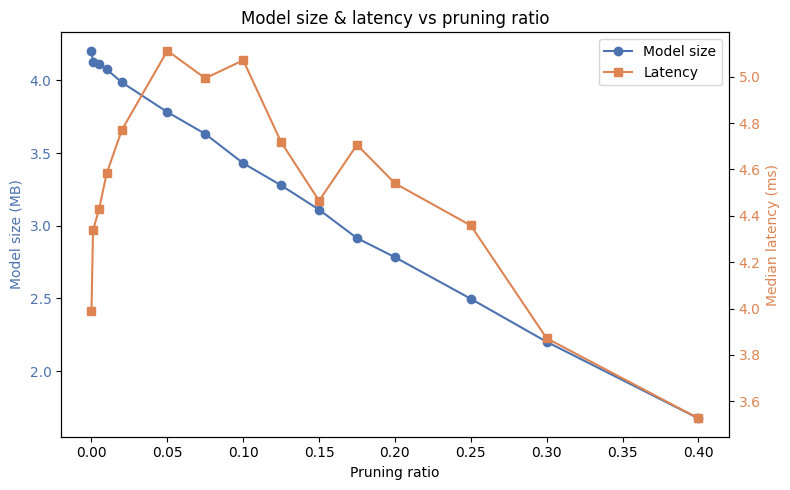

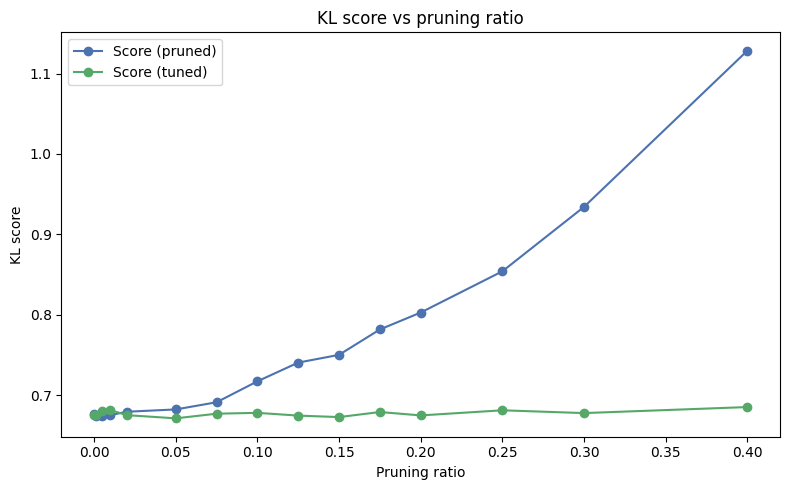

In [12]:
# Graph 1 : size et latency vs pruning ratio
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(result_df["pruning_ratio"], result_df["sizes"], marker='o', color='#4C72B0', label='Model size')
ax2.plot(result_df["pruning_ratio"], result_df["latency"], marker='s', color='#DD8452', label='Latency')

ax1.set_xlabel("Pruning ratio")
ax1.set_ylabel("Model size (MB)", color='#4C72B0')
ax2.set_ylabel("Median latency (ms)", color='#DD8452')

ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#DD8452')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Model size & latency vs pruning ratio")
plt.tight_layout()
plt.show()

# Graph 2 : score et score_tuned vs pruning ratio
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(result_df["pruning_ratio"], result_df["score"], marker='o', color='#4C72B0', label='Score (pruned)')
ax.plot(result_df["pruning_ratio"], result_df["score_tuned"], marker='o', color='#55A868', label='Score (tuned)')

ax.set_xlabel("Pruning ratio")
ax.set_ylabel("KL score")
ax.legend(loc='upper left')

plt.title("KL score vs pruning ratio")
plt.tight_layout()
plt.show()

In [9]:
result_df.to_csv(DATA_DIR / "pruning_results.csv", index=False)